# Walmart Sales Forecasting: Hierarchical Time Series Analysis
This notebook performs an end-to-end forecasting task on the Walmart Sales dataset, covering data loading, cleaning, exploratory analysis, and advanced hierarchical forecasting using the Nixtla ecosystem.

In [1]:
# General imports
import numpy as np
import pandas as pd
import os, sys, gc, time, warnings, pickle, psutil, random

from math import ceil

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')



## Data Preparation
In this section, we load the datasets (features, stores, and training data) and perform initial preprocessing, including date conversions and merging the dataframes into a unified structure.

In [2]:
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")

print("Path to dataset files:", path)

# Load the datasets using the downloaded path
featuresdf = pd.read_csv(f'{path}/features.csv')
storesdf = pd.read_csv(f'{path}/stores.csv')
traindf = pd.read_csv(f'{path}/train.csv')

# Display the first few rows of the training data
display(traindf.head())

Path to dataset files: /kaggle/input/walmart-sales-forecast


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
###testdf['Date']=pd.to_datetime(testdf['Date'])
traindf['Date']=pd.to_datetime(traindf['Date'])
featuresdf['Date']=pd.to_datetime(featuresdf['Date'])

In [5]:
df1=traindf.merge(featuresdf,how='left',indicator=False,on=['Store','Date']).merge(storesdf,how='left',indicator=False)

In [6]:
##tester=testdf.merge(featuresdf,how='left',indicator=False,on=['Store','Date']).merge(storesdf,how='left',indicator=False)

In [7]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328


### Initial Data Inspection
We use `info()` and `describe()` to identify anomalies such as negative sales or missing values in the Markdown columns.

Just from this we can notice anomalous values violating integrity rules like minimum weekly_sales being negative , minimum temperature being negative as well

In [8]:
###tester.info()
###tester.describe()

In [9]:
df1.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [10]:
df1['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

As we can see there are invalid values present in the Weekly_sales column as well as missing value in other columns and a lack of optimization with datatypes

In [11]:
df1['Weekly_Sales']=np.abs(df1['Weekly_Sales'])
df1['Weekly_Sales'].describe()

count    421570.000000
mean      15981.676377
std       22710.889199
min           0.000000
25%        2079.757500
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [12]:
df1[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']]=df1[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(-1)
###tester[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']]=tester[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(-1)

In [13]:
## Simple "Memory profilers" to see memory usage
def get_memory_usage():
    return np.round(psutil.Process(os.getpid()).memory_info()[0]/2.**30, 2)

def sizeof_fmt(num, suffix='B'):
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f%s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f%s%s" % (num, 'Yi', suffix)

In [14]:
## Memory Reducer
# :df pandas dataframe to reduce size             # type: pd.DataFrame()
# :verbose                                        # type: bool
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                       df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Type']=df1['Type'].astype('category')
df1=reduce_mem_usage(df1)

Mem. usage decreased to 19.70 Mb (57.4% reduction)


### Memory Optimization
The `reduce_mem_usage` function optimizes the data types of each column to minimize the memory footprint, which is crucial for handling large hierarchical datasets.

# Exploratory data analysis

## General insights

### Total department profits ordered from lowest to highest

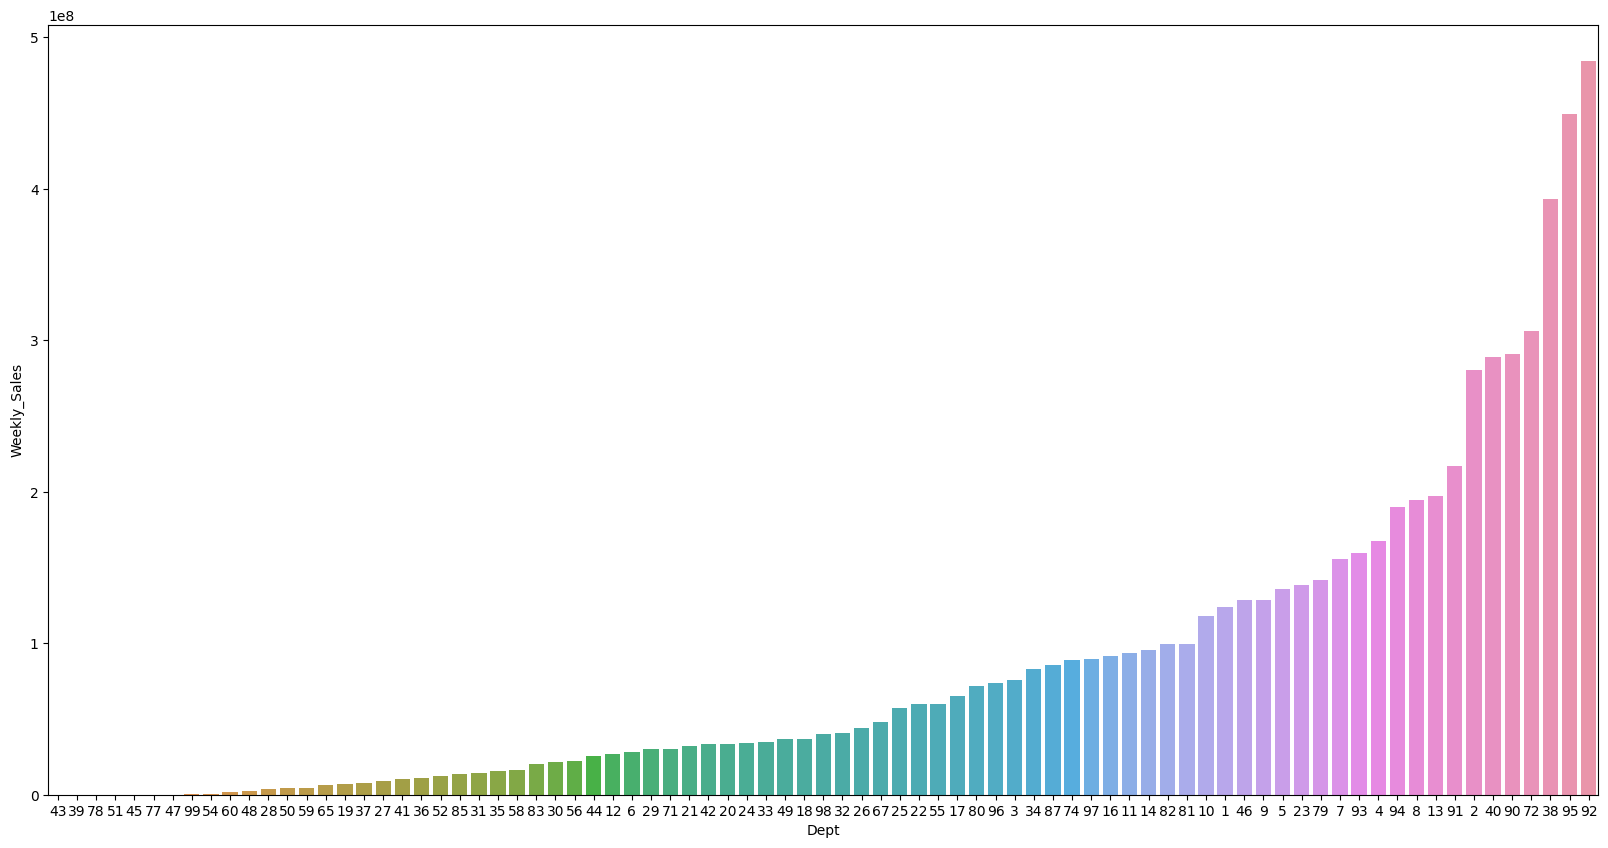

In [15]:
plt.figure(figsize=(20, 10))
D=df1[['Store','Dept','Weekly_Sales']].groupby(['Dept']).sum().sort_values(by='Weekly_Sales',ascending=True).reset_index(drop=False)
sns.barplot(x=D['Dept'],y=D.Weekly_Sales,order=D['Dept'])
plt.xticks(rotation=0)
plt.show()


### Total Store profits ordered from lowest to highest

In [16]:
df1['Date'].iloc[0]

Timestamp('2010-02-05 00:00:00')

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

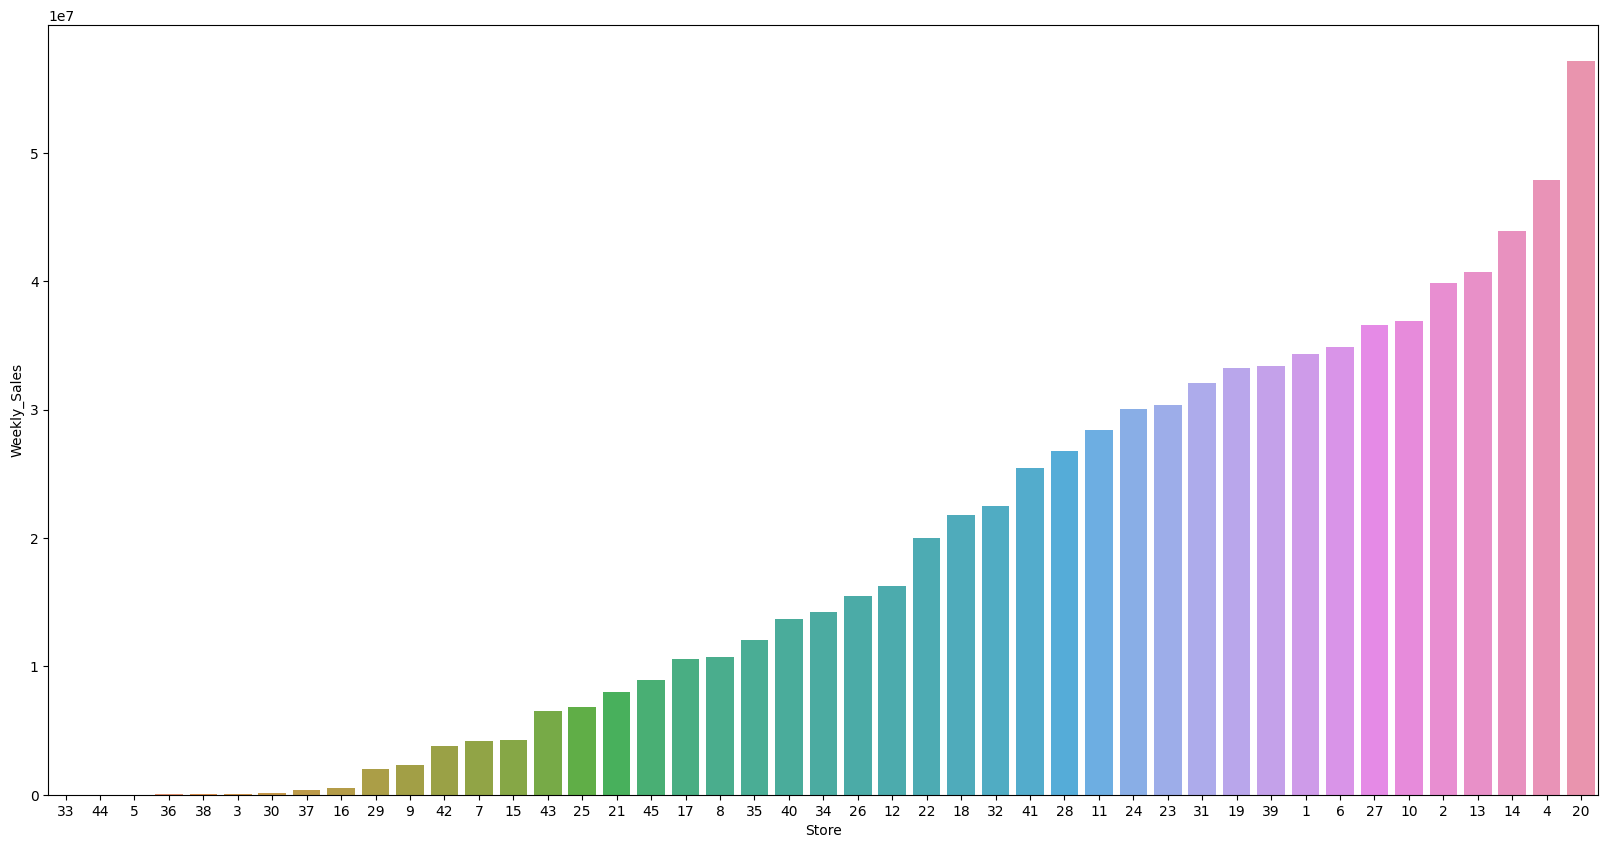

In [17]:
plt.figure(figsize=(20, 10))
S=df1[['Store','Dept','Weekly_Sales']].groupby(['Store']).sum().sort_values(by='Weekly_Sales',ascending=True).reset_index(drop=False)
sns.barplot(x=S['Store'],y=D.Weekly_Sales,order=S['Store'])

### Sales contributions of each department for each store

<Axes: xlabel='Store', ylabel='Dept'>

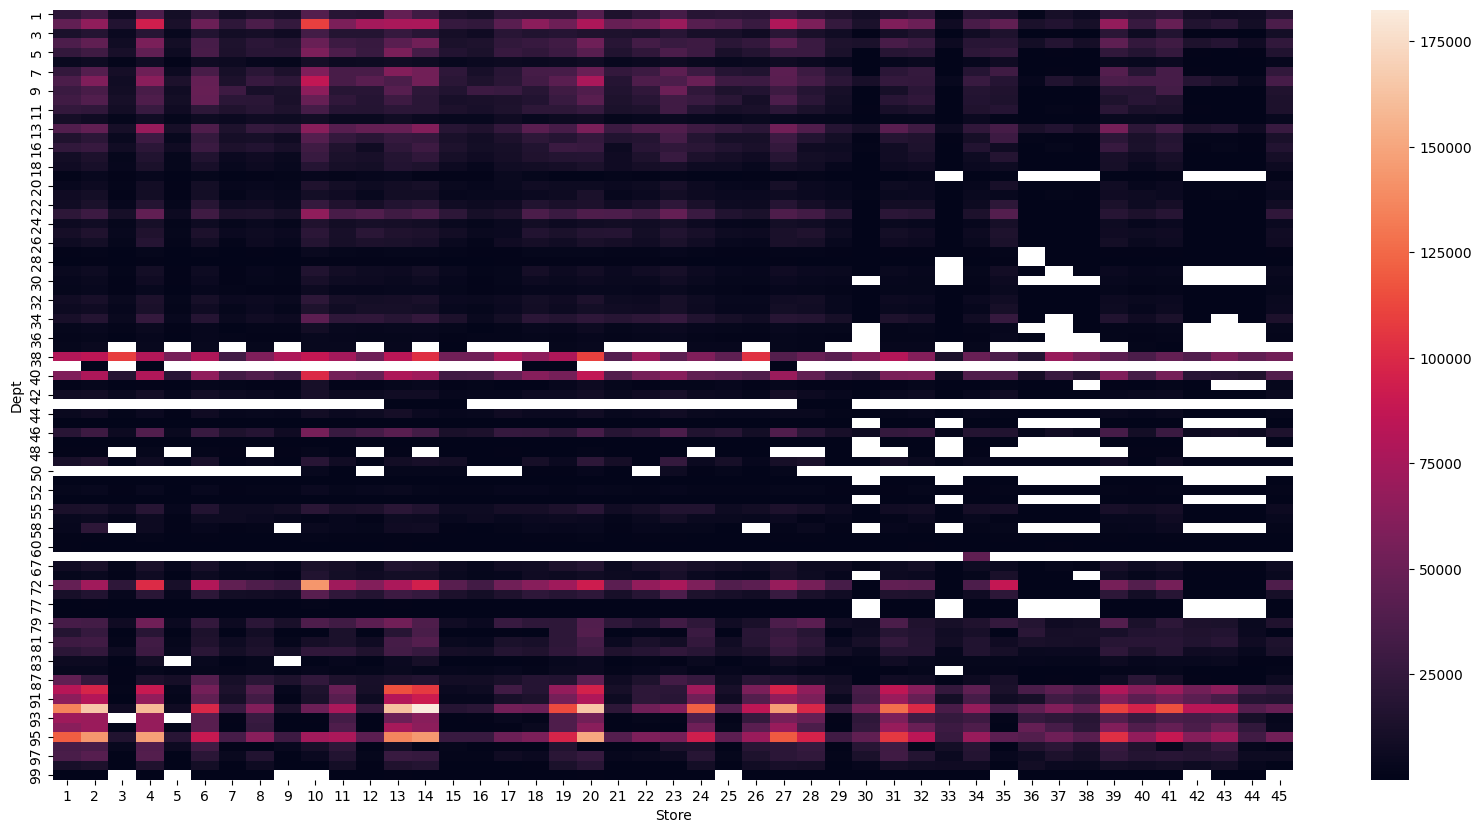

In [18]:
stacked_data = df1.pivot_table(
    index='Dept',
    columns='Store',
    values='Weekly_Sales',
    aggfunc='mean'
)
plt.figure(figsize=(20, 10))
sns.heatmap(stacked_data)

### Heatmap Analysis
The heatmap above visualizes the mean weekly sales across different departments and stores, highlighting which department-store combinations are the highest contributors to total revenue.

## Seasonality

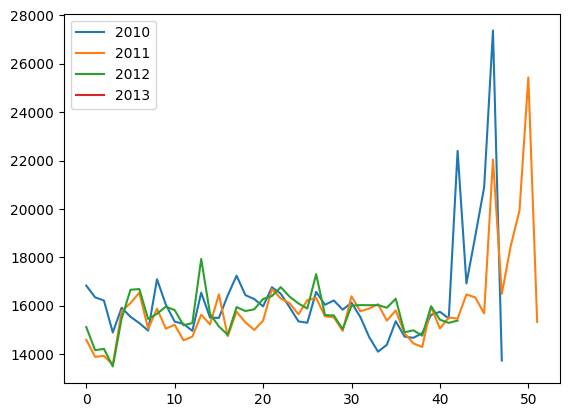

In [19]:
year1M=df1.loc[df1['Date'].dt.year==2010,['Date','Weekly_Sales']].groupby(['Date']).mean()
year2M=df1.loc[df1['Date'].dt.year==2011,['Date','Weekly_Sales']].groupby(['Date']).mean()
year3M=df1.loc[df1['Date'].dt.year==2012,['Date','Weekly_Sales']].groupby(['Date']).mean()
year4M=df1.loc[df1['Date'].dt.year==2013,['Date','Weekly_Sales']].groupby(['Date']).mean()
plt.plot(year1M.reset_index(drop=True),label="2010")
plt.plot(year2M.reset_index(drop=True),label="2011")
plt.plot(year3M.reset_index(drop=True),label="2012")
plt.plot(year4M.reset_index(drop=True),label="2013")
plt.legend()
plt.show()

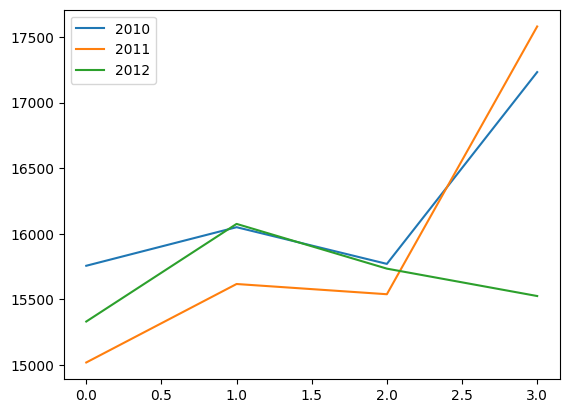

In [20]:
df1['quarter']=df1['Date'].dt.quarter
year1M=df1.loc[df1['Date'].dt.year==2010,['quarter','Weekly_Sales']].groupby(['quarter']).mean()
year2M=df1.loc[df1['Date'].dt.year==2011,['quarter','Weekly_Sales']].groupby(['quarter']).mean()
year3M=df1.loc[df1['Date'].dt.year==2012,['quarter','Weekly_Sales']].groupby(['quarter']).mean()
plt.plot(year1M.reset_index(drop=True),label="2010")
plt.plot(year2M.reset_index(drop=True),label="2011")
plt.plot(year3M.reset_index(drop=True),label="2012")
plt.legend()
plt.show()


In [21]:
del year1M
del year2M
del year3M

d=pd.DataFrame()
def lagfeatures(df):
    target_map=df["Weekly_Sales"].to_dict()
    df['lag1']=(df.index-pd.Timedelta("7 days")).map(target_map)
    df['lag2']=((df.index-pd.Timedelta("14 days")).map(target_map))
    df['lag3']=(df.index-pd.Timedelta("21 days")).map(target_map)
    return(df)

df=lagfeatures(df)
df.tail()

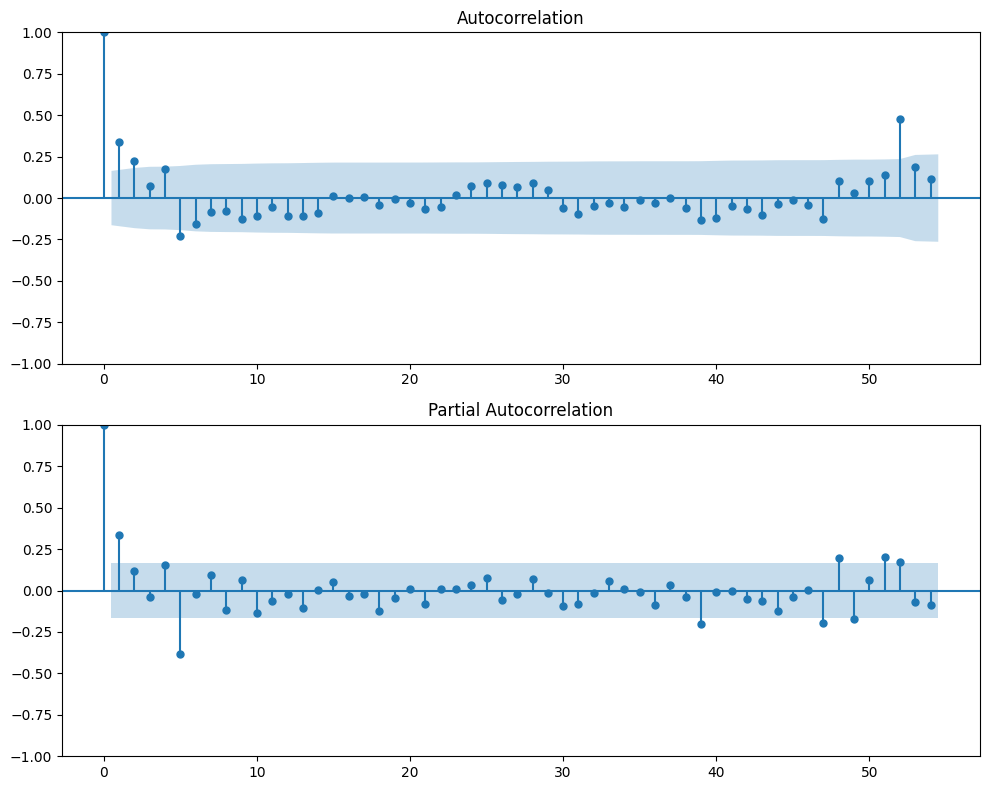

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL



fig, ax = plt.subplots(2, 1, figsize=(10, 8))

seda0 = df1[['Date', 'Weekly_Sales']].groupby('Date').sum()


plot_acf(seda0['Weekly_Sales'], lags=54, ax=ax[0])
plot_pacf(seda0['Weekly_Sales'], lags=54, ax=ax[1])

plt.tight_layout()
plt.show()

#### The acf and pacf plots dont showcase obvious parameters for an ARIMA model besides a 1 year seasonality

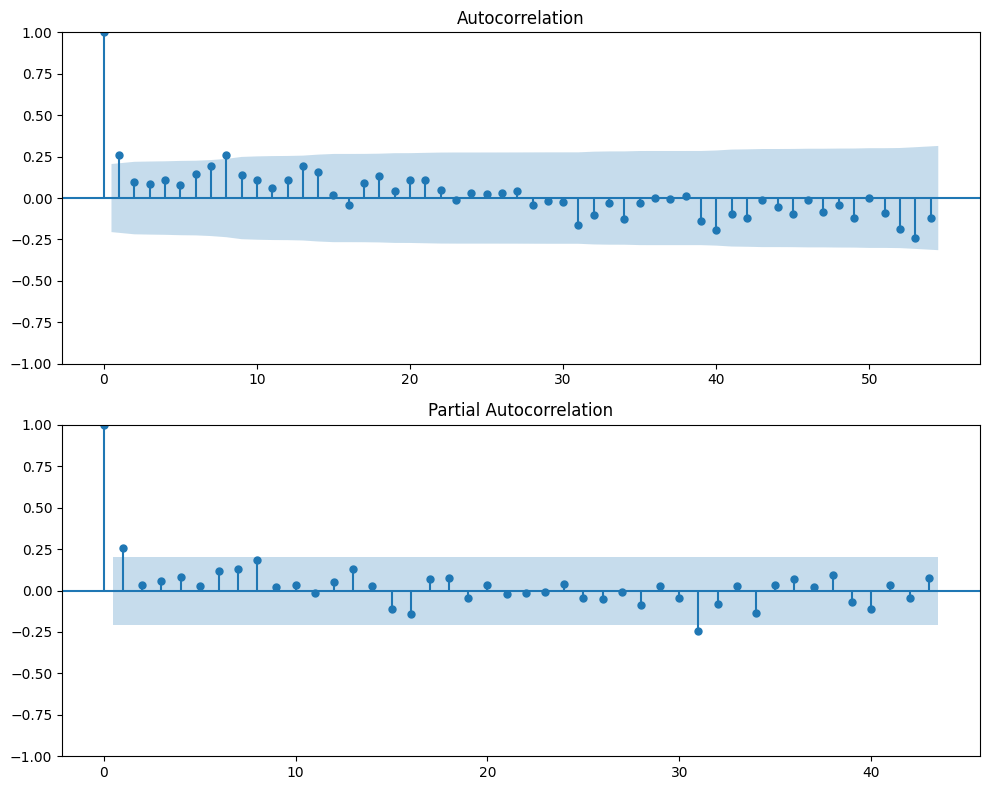

In [23]:
seda01=seda0.diff(52)
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

seda0 = df1[['Date', 'Weekly_Sales']].groupby('Date').sum()


plot_acf(seda01['Weekly_Sales'].dropna(), lags=54, ax=ax[0])
plot_pacf(seda01['Weekly_Sales'].dropna(), lags=43, ax=ax[1])

plt.tight_layout()
plt.show()

A 1 year differenciation doesnt help.

#### Naive STL

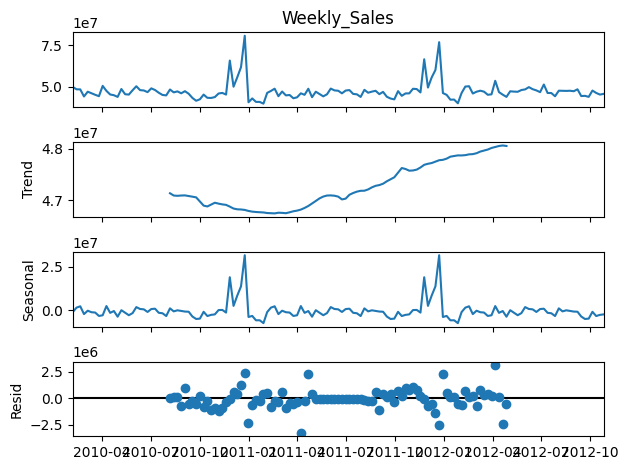

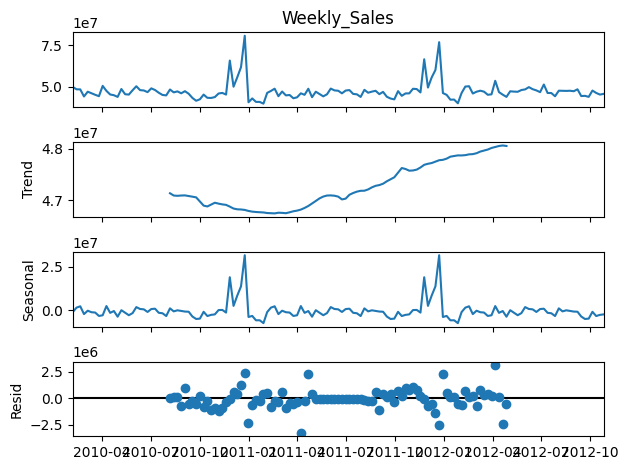

In [24]:
import statsmodels.api as sm

res = sm.tsa.seasonal_decompose(seda0['Weekly_Sales'])
res.plot()

#### Seasonal trend decomposition using LOESS (Locally estimated scatterplot smoothing)

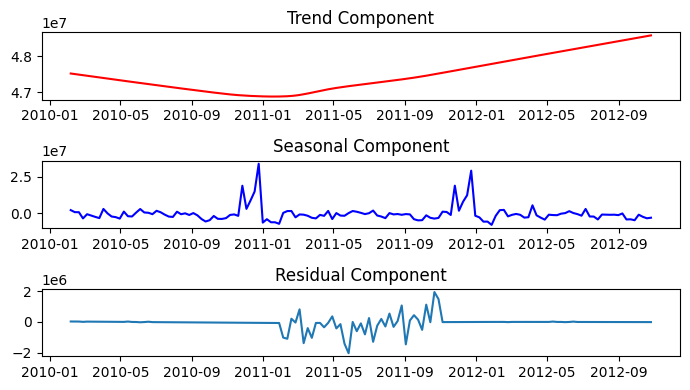

In [25]:
stl = STL(seda0['Weekly_Sales'], seasonal=55,period=52, robust=True)
result = stl.fit()

# Plot the decomposition components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 4))

ax1.plot(seda0.index, result.trend, label='Trend', color='red')
ax1.set_title('Trend Component')
ax2.plot(seda0.index, result.seasonal, label='Seasonal', color='blue')
ax2.set_title('Seasonal Component')
ax3.plot(seda0.index, result.resid, label='Residual')
ax3.set_title('Residual Component')
plt.tight_layout()
plt.show()

## Feature selection and feature engineering

#### In many cases , methods like studying correlation between features and correlation between features and the target help eliminate noise and multicolinearity issues , it is however lacking / incomplete as not all signals are linear and the forecasting methods that are capable of receiving exogenous feature that we are gonna be using later on ( namely SOTA tree models like xgboost, catboost and lgbm) are capable of capturing non linear signals.

In [26]:
!pip install BorutaShap

In [27]:
import scipy.stats

# 1. Recreate the old binom_test using the new binomtest
def patched_binom_test(x, n=None, p=0.5, alternative='two-sided'):
    return scipy.stats.binomtest(k=x, n=n, p=p, alternative=alternative).pvalue

# 2. Inject it into scipy.stats so BorutaShap can find it
scipy.stats.binom_test = patched_binom_test



In [28]:
df1[['Store','Dept']].nunique()

Store    45
Dept     81
dtype: int64

import pandas as pd
from xgboost import XGBRegressor
from BorutaShap import BorutaShap
X=df1.drop(['Weekly_Sales'],axis=1)
y=df1['Weekly_Sales']
model = XGBClassifier(random_state=42)

Feature_Selector = BorutaShap(model=model,
                              importance_measure='shap',
                              classification=True)

Feature_Selector.fit(X=X, y=y, n_trials=50, sample=False)
Feature_Selector.plot(which_features='all')
subset_X = Feature_Selector.Subset()

print("\n--- Feature Selection Complete ---")
print(f"Original number of features: {X.shape[1]}")
print(f"Selected number of features: {subset_X.shape[1]}")

Since the sales are differentiatied by store and then department we have a hierarchical forecasting problem with 3 levels where level 1 would be the sum of the sales accross all stores and departments then level 2 would be the sum of all sales for all departments of a store and level 3 would be the sales of a signle department of a single store. These add up to around 3691 timeseries

Running statistical forecasts on large hierarchichal timeseries data manually is a waste of time as the number of timeseries data is too large. Here we introduce automl libraries.

We will also be preparing other automl libraries we will be using along the road all belonging to the nixtla opensource (free for commercial use) ecosystem

In [29]:
!pip install nixtla
!pip install StatsForcast
!pip install mlforecast
!pip install neuralforecast
!pip install hierarchicalforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.4/449.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.7 MB/s eta 0:00:00
  Attempting uninstall: narwhals
    Found existing installation: narwhals 1.44.0
    Uninstalling narwhals-1.44.0:
      Successfully uninstalled narwhals-1.44.0
ERROR: Could not find a version that satisfies the requirement StatsForcast (from versions: none)
ERROR: No matching distribution found for StatsForcast
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6

Our first baseline will be a classical statistical method called exponential smoothing , we will be exploring the performance of its different variants.

In [30]:
pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
from statsforecast import StatsForecast
from statsforecast.models import HoltWinters , Naive , AutoARIMA , SimpleExponentialSmoothingOptimized
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
df1 = df1.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
df1['Total'] = 'Total'

hierarchy_spec = [['Total'],
    ['Total','Type'],
    ['Total','Type','Store'],          # Level 1 below Total
    ['Total','Type','Store', 'Dept']   # Level 2 (Bottom level)
]


train=df1.loc[df1['ds']<='2012-01-06 00:00:00']
test=df1.loc[df1['ds']>'2012-01-06 00:00:00']
valid_combos = train[['Store', 'Dept']].drop_duplicates()



# Filter the test set to ONLY keep those valid combos
test_pruned = test.merge(valid_combos, on=['Store', 'Dept'], how='inner')

ids_with_enough_test = test_pruned.groupby(['Total','Type','Store', 'Dept']).size()
ids_with_enough_test = ids_with_enough_test[ids_with_enough_test >= 38].reset_index()
ids_with_enough_test=ids_with_enough_test.drop([0],axis=1)
trainfiltered=train.merge(ids_with_enough_test,on=['Total','Type','Store', 'Dept'],how='left')
test_prunedfiltered=test_pruned.merge(ids_with_enough_test,on=['Total','Type','Store', 'Dept'],how='left')
Y_dfR, S_dfR, tagsR = aggregate(df=trainfiltered, spec=hierarchy_spec)
Y_dfT, S_dfT, tagsT = aggregate(df=test_prunedfiltered, spec=hierarchy_spec)

* Y_df : The Aggregated Data
* S_df : The Summing Matrix
* tags : The Metadata Dictionary (aka the different ids for every level demonstrated in a dictionary)

In [32]:

models = [HoltWinters(season_length=52, error_type='A'),SimpleExponentialSmoothingOptimized()
         ]
           # 'A' for Additive, 'M' for Multiplicative
sf = StatsForecast(
    models=models,
    freq='W-Fri',
    n_jobs=-1,
    fallback_model=Naive()
)


In [33]:
forecasts_df = sf.forecast(df=Y_dfR, h=54,fitted=True)


Y_fitted_df = sf.forecast_fitted_values()

In [34]:
reconcilers = [
    BottomUp(),
    MinTrace(method='mint_shrink') # Optimal reconciliation using residual variance
]

# Initialize the reconciler
hrec = HierarchicalReconciliation(reconcilers=reconcilers)

# Apply reconciliation
# We pass the base predictions, the fitted values (for MinT's variance calculations),
# the S matrix (which defines the hierarchy tree), and the tags.
Y_rec_df = hrec.reconcile(
    Y_hat_df=forecasts_df,
    Y_df=Y_fitted_df,
    S_df=S_dfR,
    tags=tagsR
)

print(Y_rec_df.head())

  unique_id         ds  HoltWinters      SESOpt  HoltWinters/BottomUp  \
0     Total 2012-01-13   40699472.0  53416684.0          4.249917e+07   
1     Total 2012-01-20   40689192.0  53416684.0          4.246657e+07   
2     Total 2012-01-27   39377288.0  53416684.0          4.113305e+07   
3     Total 2012-02-03   48344744.0  53416684.0          5.022667e+07   
4     Total 2012-02-10   49737288.0  53416684.0          5.035495e+07   

   SESOpt/BottomUp  HoltWinters/MinTrace_method-mint_shrink  \
0     5.018709e+07                             4.251144e+07   
1     5.018709e+07                             4.219002e+07   
2     5.018709e+07                             4.054016e+07   
3     5.018709e+07                             4.886957e+07   
4     5.018709e+07                             4.906842e+07   

   SESOpt/MinTrace_method-mint_shrink  
0                        4.869008e+07  
1                        4.869008e+07  
2                        4.869008e+07  
3                     

In [35]:
import matplotlib.pyplot as plt
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape

In [36]:
L=[]
for unique_id in Y_rec_df['unique_id'].unique():
    if unique_id not in Y_dfT['unique_id'].unique():
        L.append(unique_id)

In [37]:
preds = Y_rec_df.loc[~Y_rec_df['unique_id'].isin(L)]

In [38]:
'''print(preds)
print(Y_dfT)'''

'print(preds)\nprint(Y_dfT)'

In [39]:
Y_dfR

,unique_id,ds,y
0,Total,2010-02-05,4.975101e+07
1,Total,2010-02-12,4.833692e+07
2,Total,2010-02-19,4.827881e+07
3,Total,2010-02-26,4.397231e+07
4,Total,2010-03-05,4.687396e+07
...,...,...,...
302049,Total/C/44/98,2011-12-23,4.477160e+03
302050,Total/C/44/98,2011-12-30,3.004010e+03
302051,Total/C/44/98,2012-01-06,3.170400e+03
302052,Total/C/44/99,2010-03-05,1.000000e-02


In [40]:
preds

,unique_id,ds,HoltWinters,SESOpt,HoltWinters/BottomUp,SESOpt/BottomUp,HoltWinters/MinTrace_method-mint_shrink,SESOpt/MinTrace_method-mint_shrink
0,Total,2012-01-13,4.069947e+07,5.341668e+07,4.249917e+07,5.018709e+07,4.251144e+07,4.869008e+07
1,Total,2012-01-20,4.068919e+07,5.341668e+07,4.246657e+07,5.018709e+07,4.219002e+07,4.869008e+07
2,Total,2012-01-27,3.937729e+07,5.341668e+07,4.113305e+07,5.018709e+07,4.054016e+07,4.869008e+07
3,Total,2012-02-03,4.834474e+07,5.341668e+07,5.022667e+07,5.018709e+07,4.886957e+07,4.869008e+07
4,Total,2012-02-10,4.973729e+07,5.341668e+07,5.035495e+07,5.018709e+07,4.906842e+07,4.869008e+07
...,...,...,...,...,...,...,...,...
181003,Total/C/44/98,2012-12-21,3.848142e+03,3.435197e+03,3.848142e+03,3.435197e+03,3.965869e+03,3.295984e+03
181004,Total/C/44/98,2012-12-28,1.708356e+03,3.435197e+03,1.708356e+03,3.435197e+03,1.905953e+03,3.295984e+03
181005,Total/C/44/98,2013-01-04,1.901752e+03,3.435197e+03,1.901752e+03,3.435197e+03,2.141011e+03,3.295984e+03
181006,Total/C/44/98,2013-01-11,2.285583e+03,3.435197e+03,2.285583e+03,3.435197e+03,2.607483e+03,3.295984e+03


In [41]:
actuals = Y_dfT[['unique_id', 'ds', 'y']]
actuals

,unique_id,ds,y
0,Total,2012-01-13,4.202395e+07
1,Total,2012-01-20,4.208312e+07
2,Total,2012-01-27,3.983525e+07
3,Total,2012-02-03,4.608595e+07
4,Total,2012-02-10,5.001098e+07
...,...,...,...
126401,Total/C/44/98,2012-09-28,3.429310e+03
126402,Total/C/44/98,2012-10-05,3.852340e+03
126403,Total/C/44/98,2012-10-12,3.985670e+03
126404,Total/C/44/98,2012-10-19,4.233100e+03


In [42]:


#  Merge predictions with actual ground truth
eval_df = actuals.merge(preds, on=['unique_id', 'ds'],how='left')

# Define the models we want to evaluate

models_to_evaluate = ['HoltWinters', 'HoltWinters/BottomUp', 'HoltWinters/MinTrace_method-mint_shrink','SESOpt', 'SESOpt/BottomUp', 'SESOpt/MinTrace_method-mint_shrink']

# Calculate metrics using utilsforecast
metrics_df = evaluate(
    df=eval_df,
    metrics=[rmse, mae, mape],
    models=models_to_evaluate
)

print("Model Evaluation Metrics")
# Let's look at the average error across the entire hierarchy
print(metrics_df.groupby('metric')[models_to_evaluate].median())

Model Evaluation Metrics
        HoltWinters  HoltWinters/BottomUp  \
metric                                      
mae     1063.269043           1063.269051   
mape       0.165025              0.165025   
rmse    1380.494751           1380.494711   

        HoltWinters/MinTrace_method-mint_shrink       SESOpt  SESOpt/BottomUp  \
metric                                                                          
mae                                 1089.186646  1581.265625      1581.265718   
mape                                   0.172758     0.267856         0.267856   
rmse                                1419.204739  1912.809814      1912.809871   

        SESOpt/MinTrace_method-mint_shrink  
metric                                      
mae                            1406.823994  
mape                              0.246078  
rmse                           1745.900956  


### Statistical Model Performance
The metrics show that **Holt-Winters** with a seasonal length of 52 generally outperforms the optimized Simple Exponential Smoothing (SESOpt). Hierarchical reconciliation methods like **MinTrace** slightly adjust the base forecasts to ensure consistency across the hierarchy levels.

In [43]:
print(metrics_df[['HoltWinters', 'HoltWinters/BottomUp', 'HoltWinters/MinTrace_method-mint_shrink']].sort_values(by='HoltWinters'))
print(metrics_df[['SESOpt', 'SESOpt/BottomUp', 'SESOpt/MinTrace_method-mint_shrink']].sort_values(by='SESOpt'))

      HoltWinters  HoltWinters/BottomUp  \
8675          0.0                   0.0   
5440          0.0                   0.0   
666           0.0                   0.0   
2205          0.0                   0.0   
7136          0.0                   0.0   
...           ...                   ...   
9606          NaN                   NaN   
9623          NaN                   NaN   
9672          NaN                   NaN   
9677          NaN                   NaN   
9684          NaN                   NaN   

      HoltWinters/MinTrace_method-mint_shrink  
8675                                 2.528912  
5440                               500.724516  
666                                270.257758  
2205                               510.928757  
7136                                 1.364938  
...                                       ...  
9606                                      NaN  
9623                                      NaN  
9672                                      NaN  
967

In [44]:
metrics_df.dropna(inplace=True)

In [45]:
print(metrics_df[['HoltWinters', 'HoltWinters/BottomUp', 'HoltWinters/MinTrace_method-mint_shrink']].sort_values(by='HoltWinters'))
print(metrics_df[['SESOpt', 'SESOpt/BottomUp', 'SESOpt/MinTrace_method-mint_shrink']].sort_values(by='SESOpt'))

       HoltWinters  HoltWinters/BottomUp  \
8675  0.000000e+00          0.000000e+00   
5440  0.000000e+00          0.000000e+00   
666   0.000000e+00          0.000000e+00   
2205  0.000000e+00          0.000000e+00   
7136  0.000000e+00          0.000000e+00   
...            ...                   ...   
1632  5.731311e+05          5.942261e+05   
3236  8.207387e+05          1.028987e+06   
1     1.207359e+06          1.384374e+06   
3235  1.258286e+06          1.419564e+06   
0     1.745056e+06          1.934394e+06   

      HoltWinters/MinTrace_method-mint_shrink  
8675                             2.528912e+00  
5440                             5.007245e+02  
666                              2.702578e+02  
2205                             5.109288e+02  
7136                             1.364938e+00  
...                                       ...  
1632                             5.099128e+05  
3236                             9.004186e+05  
1                                1.2426

uid='Total/C/44/71'
Y_dfR.loc[Y_dfR['unique_id']==uid]

In [46]:
l=metrics_df.loc[metrics_df['metric']=='mape',['metric','unique_id','HoltWinters']].dropna()
l.sort_values(by='HoltWinters',inplace=True)

<Axes: xlabel='HoltWinters', ylabel='Count'>

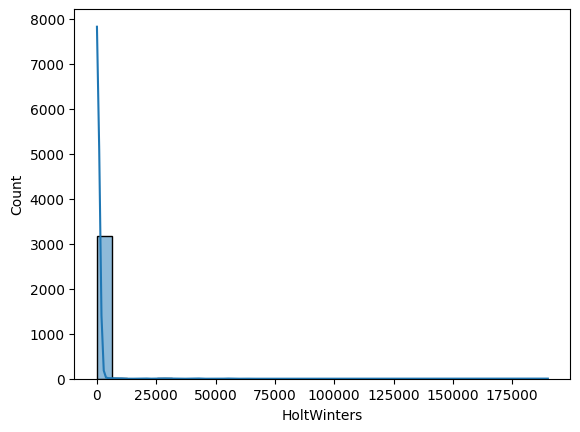

In [47]:
sns.histplot(data=l,x='HoltWinters',bins=30, kde=True)

In [48]:
l.describe()

,HoltWinters
count,3211.000000
mean,380.776032
std,5136.584250
min,0.000000
25%,0.099774
50%,0.165025
75%,0.353661
max,190052.522362


Holt-Winters Forecasting Evaluation: MAPE Distribution
1. Strong Core Performance
The model performs well for the majority of the hierarchy: half of the series have a MAPE of 16.7% or lower, and 75% are below 35.9%. This indicates reliable forecasts for series with continuous, stable demand but could be improved with longer timeseries.

2. Missing Data & Short Histories
The summary successfully evaluates 3,209 series. Series excluded from this count are typically highly sporadic or lack the historical data required for Holt-Winters to properly initialize. Furthermore, any test periods with zero actual demand result in NaN errors (due to division by zero in the MAPE formula), causing those series to drop from the metrics entirely.

3. Outliers & Metric Limitations
The massive divergence between the median (0.167) and the mean (386.9), driven by a maximum error of 190,052, highlights a well-known mathematical flaw in MAPE. For intermittent data, dividing the error by actual demand values near zero causes the percentage error to explode toward infinity, artificially skewing the mean.

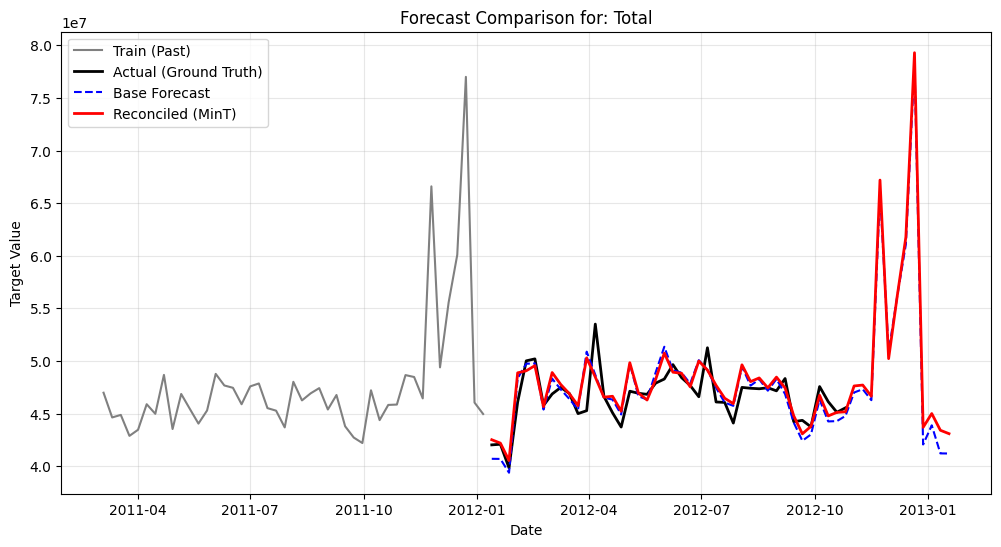

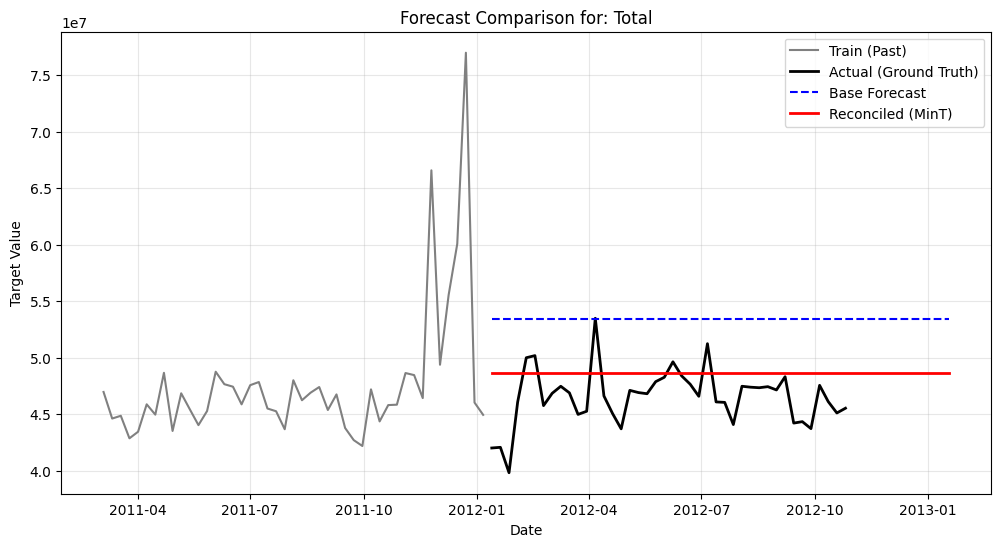

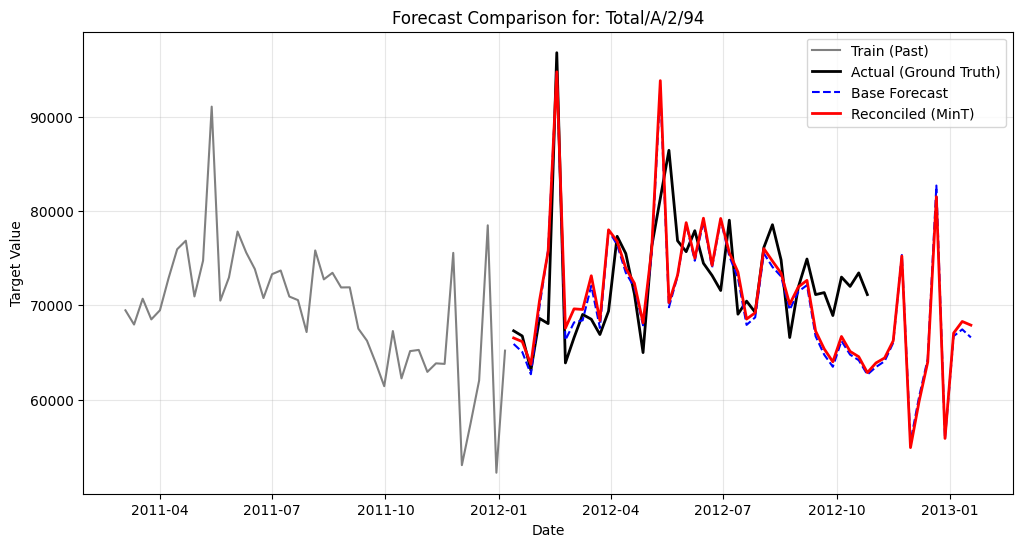

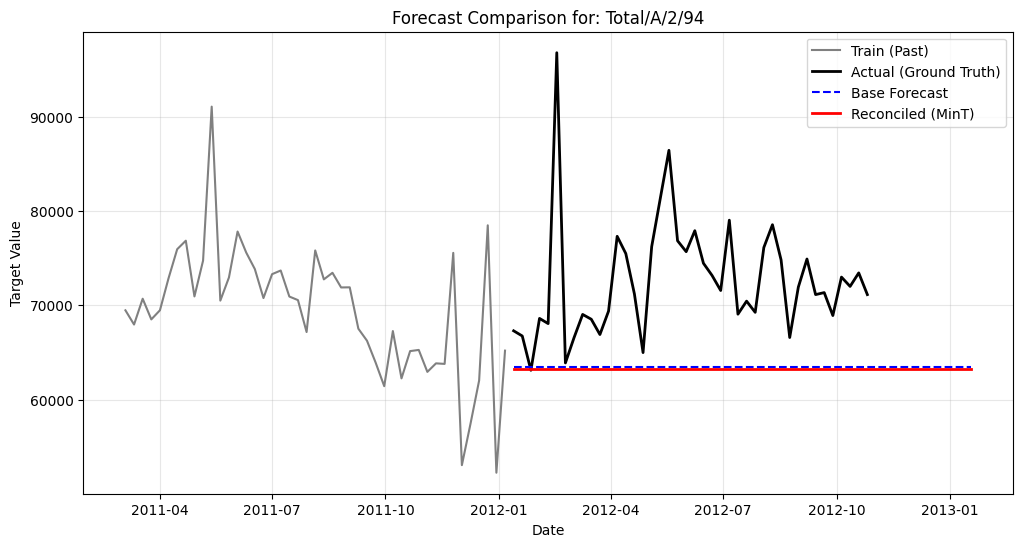

In [49]:
def plot_hierarchical_series(uid, model_name='HoltWinters'):
    """
    Plots the train, actuals, base forecast, and reconciled forecast for a specific ID.
    model_name: Change to 'HoltWinters' if using the ETS pipeline.
    """
    fig, ax = plt.subplots(figsize=(12, 6))


    train_plot = Y_dfR.loc[Y_dfR['unique_id']==uid]# if uid in Y_train_df.index else Y_train_df[Y_train_df.index == uid]
    test_plot = Y_dfT.loc[Y_dfT['unique_id']==uid]#if uid in Y_test_df.index else Y_test_df[Y_test_df.index == uid]
    pred_plot = Y_rec_df.loc[Y_rec_df['unique_id']==uid]# if uid in Y_rec_df.index else Y_rec_df[Y_rec_df.index == uid]


    ax.plot(train_plot['ds'].tail(45), train_plot['y'].tail(45), label='Train (Past)', color='gray')


    ax.plot(test_plot['ds'], test_plot['y'], label='Actual (Ground Truth)', color='black', linewidth=2)


    ax.plot(pred_plot['ds'], pred_plot[model_name], label='Base Forecast', linestyle='--', color='blue')


    ax.plot(pred_plot['ds'], pred_plot[f'{model_name}/MinTrace_method-mint_shrink'], label='Reconciled (MinT)', color='red', linewidth=2)

    ax.set_title(f"Forecast Comparison for: {uid}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Target Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

# Test the plot on the Top Level (Total Country)
plot_hierarchical_series('Total','HoltWinters')
plot_hierarchical_series('Total','SESOpt')

# Test the plot on a Bottom Level (Specific Store)
plot_hierarchical_series('Total/A/2/94','HoltWinters')
plot_hierarchical_series('Total/A/2/94','SESOpt')


In [50]:
models = [AutoARIMA(
        season_length=52,
        stepwise=True,        # Uses a faster stepwise search rather than full grid
        approximation=True,   # Uses faster approximations for model selection

    )
         ]
           # 'A' for Additive, 'M' for Multiplicative
sf = StatsForecast(
    models=models,
    freq='W-FRI',
    n_jobs=-1,
    fallback_model=Naive()
)


In [51]:
forecasts_df = sf.forecast(df=Y_dfR, h=54,fitted=True)


Y_fitted_df = sf.forecast_fitted_values()

In [52]:
reconcilers = [
    BottomUp(),
    MinTrace(method='mint_shrink') # Optimal reconciliation using residual variance
]

# Initialize the reconciler
hrec = HierarchicalReconciliation(reconcilers=reconcilers)

# Apply reconciliation
# We pass the base predictions, the fitted values (for MinT's variance calculations),
# the S matrix (which defines the hierarchy tree), and the tags.
Y_rec_df = hrec.reconcile(
    Y_hat_df=forecasts_df,
    Y_df=Y_fitted_df,
    S_df=S_dfR,
    tags=tagsR
)

print(Y_rec_df.head())

  unique_id         ds   AutoARIMA  AutoARIMA/BottomUp  \
0     Total 2012-01-13  42742504.0        4.628450e+07   
1     Total 2012-01-20  48395732.0        4.834035e+07   
2     Total 2012-01-27  45047184.0        4.666147e+07   
3     Total 2012-02-03  48769896.0        4.791759e+07   
4     Total 2012-02-10  45807420.0        4.807873e+07   

   AutoARIMA/MinTrace_method-mint_shrink  
0                           4.674111e+07  
1                           4.957900e+07  
2                           4.493076e+07  
3                           4.711017e+07  
4                           4.923375e+07  


In [53]:
import matplotlib.pyplot as plt
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape

In [54]:
'''print(Y_rec_df)
print(Y_dfT)'''

'print(Y_rec_df)\nprint(Y_dfT)'

In [55]:
L=[]
for unique_id in Y_rec_df['unique_id'].unique():
    if unique_id not in Y_dfT['unique_id'].unique():
        L.append(unique_id)

In [56]:
preds = Y_rec_df.loc[~Y_rec_df['unique_id'].isin(L)]

In [57]:
'''print(preds)
print(Y_dfT)'''

'print(preds)\nprint(Y_dfT)'

In [58]:
Y_dfR

,unique_id,ds,y
0,Total,2010-02-05,4.975101e+07
1,Total,2010-02-12,4.833692e+07
2,Total,2010-02-19,4.827881e+07
3,Total,2010-02-26,4.397231e+07
4,Total,2010-03-05,4.687396e+07
...,...,...,...
302049,Total/C/44/98,2011-12-23,4.477160e+03
302050,Total/C/44/98,2011-12-30,3.004010e+03
302051,Total/C/44/98,2012-01-06,3.170400e+03
302052,Total/C/44/99,2010-03-05,1.000000e-02


In [59]:
actuals

,unique_id,ds,y
0,Total,2012-01-13,4.202395e+07
1,Total,2012-01-20,4.208312e+07
2,Total,2012-01-27,3.983525e+07
3,Total,2012-02-03,4.608595e+07
4,Total,2012-02-10,5.001098e+07
...,...,...,...
126401,Total/C/44/98,2012-09-28,3.429310e+03
126402,Total/C/44/98,2012-10-05,3.852340e+03
126403,Total/C/44/98,2012-10-12,3.985670e+03
126404,Total/C/44/98,2012-10-19,4.233100e+03


In [60]:
preds

,unique_id,ds,AutoARIMA,AutoARIMA/BottomUp,AutoARIMA/MinTrace_method-mint_shrink
0,Total,2012-01-13,4.274250e+07,4.628450e+07,4.674111e+07
1,Total,2012-01-20,4.839573e+07,4.834035e+07,4.957900e+07
2,Total,2012-01-27,4.504718e+07,4.666147e+07,4.493076e+07
3,Total,2012-02-03,4.876990e+07,4.791759e+07,4.711017e+07
4,Total,2012-02-10,4.580742e+07,4.807873e+07,4.923375e+07
...,...,...,...,...,...
181003,Total/C/44/98,2012-12-21,3.625906e+03,3.625906e+03,3.519247e+03
181004,Total/C/44/98,2012-12-28,3.625908e+03,3.625908e+03,3.525993e+03
181005,Total/C/44/98,2013-01-04,3.625902e+03,3.625902e+03,3.508488e+03
181006,Total/C/44/98,2013-01-11,3.625899e+03,3.625899e+03,3.494855e+03


In [61]:
actuals = Y_dfT[['unique_id', 'ds', 'y']]

#  Merge predictions with actual ground truth
eval_df = actuals.merge(preds, on=['unique_id', 'ds'],how='left')

# Define the models we want to evaluate

models_to_evaluate = ['AutoARIMA', 'AutoARIMA/BottomUp', 'AutoARIMA/MinTrace_method-mint_shrink']

# Calculate metrics using utilsforecast
metrics_df = evaluate(
    df=eval_df,
    metrics=[rmse, mae, mape],
    models=models_to_evaluate
)

print("Model Evaluation Metrics")
# Let's look at the average error across the entire hierarchy
print(metrics_df.groupby('metric')[models_to_evaluate].median())

Model Evaluation Metrics
          AutoARIMA  AutoARIMA/BottomUp  AutoARIMA/MinTrace_method-mint_shrink
metric                                                                        
mae     1380.514648         1380.514730                            1449.352604
mape       0.236516            0.236516                               0.243081
rmse    1675.844849         1675.844883                            1753.686948


### AutoARIMA vs. Exponential Smoothing
Compared to Holt-Winters, the AutoARIMA models show different error distributions. While ARIMA is better at capturing complex autocorrelation, the simple seasonal smoothing of Holt-Winters appears quite robust for this specific dataset's weekly frequency.

In [62]:
metrics_df.sort_values(by='AutoARIMA')

,unique_id,metric,AutoARIMA,AutoARIMA/BottomUp,AutoARIMA/MinTrace_method-mint_shrink
9343,Total/C/30,mape,0.020667,0.028444,0.022847
9404,Total/C/37,mape,0.026849,0.031137,0.025858
7704,Total/A/39/8,mape,0.028250,0.028250,0.031984
9586,Total/C/43,mape,0.030293,0.032496,0.031290
9457,Total/C/37/91,mape,0.031134,0.031134,0.054249
...,...,...,...,...,...
9606,Total/C/43/32,mape,NaN,NaN,NaN
9623,Total/C/43/71,mape,NaN,NaN,NaN
9672,Total/C/44/44,mape,NaN,NaN,NaN
9677,Total/C/44/55,mape,NaN,NaN,NaN


uid='Total/C/44/71'
Y_dfR.loc[Y_dfR['unique_id']==uid]

In [63]:
l=metrics_df.loc[metrics_df['metric']=='mape',['metric','unique_id','AutoARIMA']].dropna()
l.sort_values(by='AutoARIMA',inplace=True)

<Axes: xlabel='AutoARIMA', ylabel='Count'>

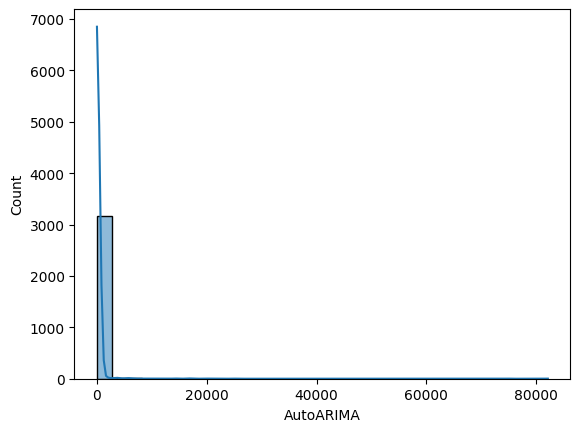

In [64]:
sns.histplot(data=l,x='AutoARIMA',bins=30, kde=True)

In [65]:
l.describe()

,AutoARIMA
count,3211.000000
mean,185.683376
std,2531.007330
min,0.020667
25%,0.125064
50%,0.236516
75%,0.518072
max,82147.971098


Holt-Winters Forecasting Evaluation: MAPE Distribution
1. Strong Core Performance
The model performs well for the majority of the hierarchy: half of the series have a MAPE of 16.7% or lower, and 75% are below 35.9%. This indicates reliable forecasts for series with continuous, stable demand but could be improved with longer timeseries.

2. Missing Data & Short Histories
The summary successfully evaluates 3,209 series. Series excluded from this count are typically highly sporadic or lack the historical data required for Holt-Winters to properly initialize. Furthermore, any test periods with zero actual demand result in NaN errors (due to division by zero in the MAPE formula), causing those series to drop from the metrics entirely.

3. Outliers & Metric Limitations
The massive divergence between the median (0.167) and the mean (386.9), driven by a maximum error of 190,052, highlights a well-known mathematical flaw in MAPE. For intermittent data, dividing the error by actual demand values near zero causes the percentage error to explode toward infinity, artificially skewing the mean.

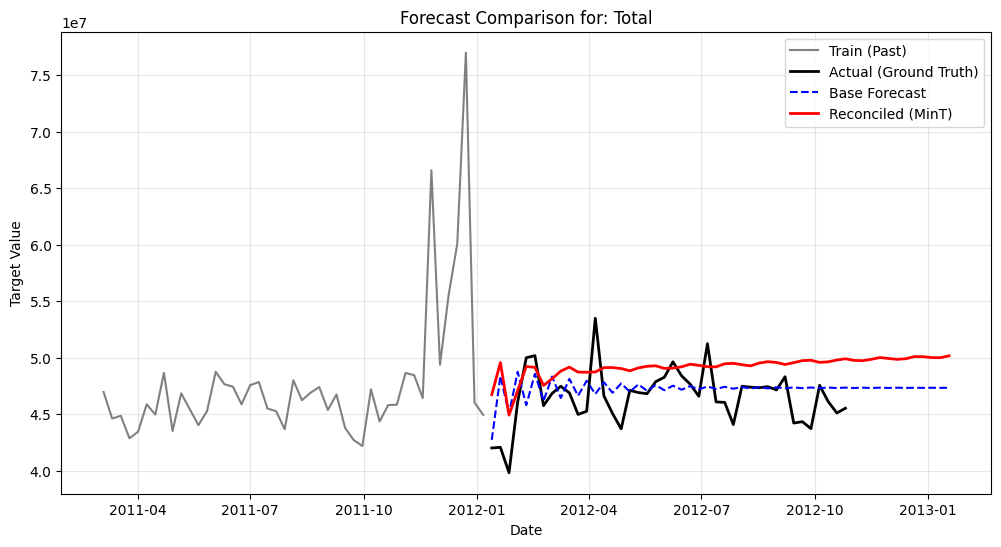

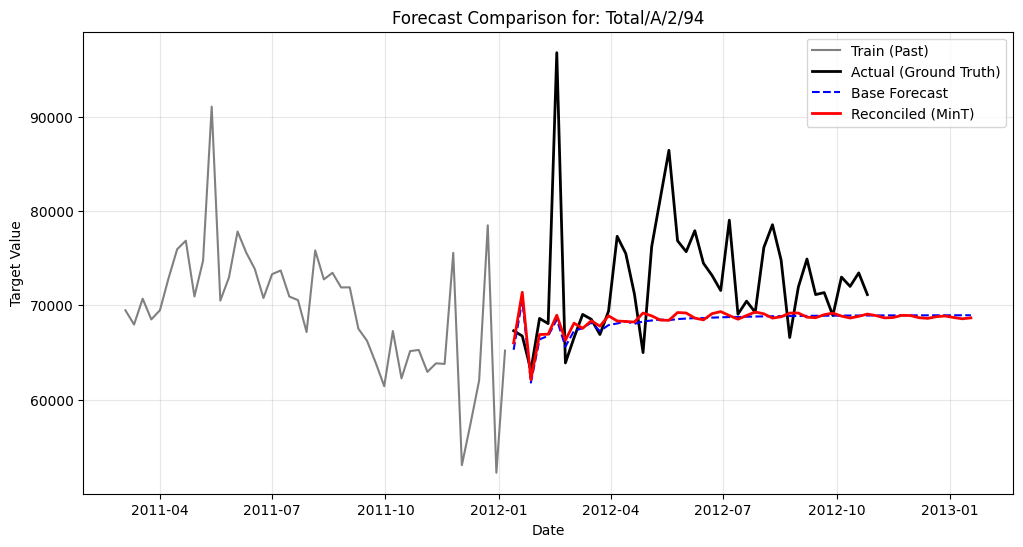

In [66]:
def plot_hierarchical_series(uid, model_name='AutoARIMA'):
    """
    Plots the train, actuals, base forecast, and reconciled forecast for a specific ID.
    model_name: Change to 'HoltWinters' if using the ETS pipeline.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # 1. Get the data for this specific unique_id
    train_plot = Y_dfR.loc[Y_dfR['unique_id']==uid]# if uid in Y_train_df.index else Y_train_df[Y_train_df.index == uid]
    test_plot = Y_dfT.loc[Y_dfT['unique_id']==uid]#if uid in Y_test_df.index else Y_test_df[Y_test_df.index == uid]
    pred_plot = Y_rec_df.loc[Y_rec_df['unique_id']==uid]# if uid in Y_rec_df.index else Y_rec_df[Y_rec_df.index == uid]

    # 2. Plot Historical Training Data (last 45 days for better zoom)
    ax.plot(train_plot['ds'].tail(45), train_plot['y'].tail(45), label='Train (Past)', color='gray')

    # 3. Plot Actual Test Data
    ax.plot(test_plot['ds'], test_plot['y'], label='Actual (Ground Truth)', color='black', linewidth=2)

    # 4. Plot the Base (Unreconciled) Forecast
    ax.plot(pred_plot['ds'], pred_plot[model_name], label='Base Forecast', linestyle='--', color='blue')

    # 5. Plot the MinT Reconciled Forecast
    ax.plot(pred_plot['ds'], pred_plot[f'{model_name}/MinTrace_method-mint_shrink'], label='Reconciled (MinT)', color='red', linewidth=2)

    ax.set_title(f"Forecast Comparison for: {uid}")
    ax.set_xlabel("Date")

    ax.set_ylabel("Target Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

# Test the plot on the Top Level (Total Country)
plot_hierarchical_series('Total')

# Test the plot on a Bottom Level (Specific Store)
plot_hierarchical_series('Total/A/2/94')

We are gonna be working with SARIMAX next

In [67]:
'''df1.columns'''

'df1.columns'

In [68]:
from statsforecast import StatsForecast
from statsforecast.models import HoltWinters , Naive
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

# Prepare dataframe names
df1 = df1.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
df1['Total'] = 'Total'

# Define hierarchy levels
hierarchy_spec = [
    ['Total'],
    ['Total','Type'],
    ['Total','Type','Store'],
    ['Total','Type','Store', 'Dept']
]

# Initial split
train = df1.loc[df1['ds'] <= '2012-01-01 00:00:00']
test = df1.loc[df1['ds'] > '2012-01-01 00:00:00']

# Filter to ensure we only forecast series present in training
valid_combos = train[['Store', 'Dept']].drop_duplicates()
test_pruned = test.merge(valid_combos, on=['Store', 'Dept'], how='inner')

# Identify series with at least 38 samples in the test set for evaluation
ids_with_enough_test = test_pruned.groupby(['Total','Type','Store', 'Dept']).size()
ids_with_enough_test = ids_with_enough_test[ids_with_enough_test >= 38].reset_index()
ids_with_enough_test = ids_with_enough_test.drop([0], axis=1)

# Filter train and test sets BEFORE aggregation
trainfiltered = train.merge(ids_with_enough_test, on=['Total','Type','Store', 'Dept'], how='inner')
test_prunedfiltered = test_pruned.merge(ids_with_enough_test, on=['Total','Type','Store', 'Dept'], how='inner')

# Aggregation with exogenous features
my_exog_rules = {'IsHoliday_x':'max','Temperature':'mean','Fuel_Price':'mean','CPI':'max','Unemployment':'max','Size':'mean'}

Y_dfR, S_dfR, tagsR = aggregate(df=trainfiltered, spec=hierarchy_spec, exog_vars=my_exog_rules)
Y_dfT, S_dfT, tagsT = aggregate(df=test_prunedfiltered, spec=hierarchy_spec, exog_vars=my_exog_rules)

Because the aggregate() function outputs a single pandas DataFrame, every row—whether it is the 'Total' level or a bottom 'Dept' level—must physically have the exact same columns. You cannot structurally drop a column for only some rows.

However, if an exogenous variable (like a localized department discount) is completely meaningless when rolled up to the 'Total' or 'Country' level, if we set to a constant 0 the model will mathematically ignore it.

In [69]:
'''Y_dfR'''

'Y_dfR'

In [70]:
from statsforecast.models import AutoARIMA

models = [AutoARIMA(season_length=52)]
sf = StatsForecast(
    models=models,
    freq='W-FRI',
    n_jobs=-1,
    fallback_model=Naive()
)

# Dynamically get the actual exogenous column names
actual_exog_cols_in_df = [col for col in Y_dfR.columns if col not in ['unique_id', 'ds', 'y']]
cols_for_future_exog = ['unique_id', 'ds'] + actual_exog_cols_in_df

# 1. Identify UIDs that are aggregates (Total, Type, Store levels)
aggregate_uids = np.concatenate([
    tagsR['Total'],
    tagsR['Total/Type'],
    tagsR['Total/Type/Store']
])

# 2. Identify ALL UIDs including bottom level (Dept) that have sufficient test data
actual_future_counts = Y_dfT.groupby('unique_id').size()
uids_with_sufficient_future_data = actual_future_counts[actual_future_counts >= 38].index

# 3. Combine them: aggregates and validated bottom-level series
ids_to_forecast = list(set(aggregate_uids) | set(uids_with_sufficient_future_data))

# 4. Filter DataFrames
Y_dfR_for_forecast = Y_dfR[Y_dfR['unique_id'].isin(ids_to_forecast)].copy()
future_exog = Y_dfT[Y_dfT['unique_id'].isin(ids_to_forecast)].copy()
future_exog = future_exog.sort_values(by=['unique_id', 'ds'])
future_exog = future_exog.groupby('unique_id').head(38)[cols_for_future_exog]

# 5. Run Forecast
forecasts_sarimax = sf.forecast(
    df=Y_dfR_for_forecast,
    h=38,
    fitted=True,
    X_df=future_exog
)

Y_fitted_sarimax = sf.forecast_fitted_values()

In [71]:
Y_dfR_for_forecast.describe()

,ds,y,Temperature_mean,Fuel_Price_mean,CPI_max,Unemployment_max,Size_mean
count,284603,2.846030e+05,284603.000000,284603.000000,284603.0000,284603.000000,284603.000000
mean,2011-01-18 16:10:53.811801088,6.625880e+04,58.949322,3.211184,NaN,NaN,138039.063489
min,2010-02-05 00:00:00,0.000000e+00,-2.060547,2.472656,126.0625,4.421875,34875.000000
25%,2010-07-30 00:00:00,2.755550e+03,45.312500,2.808594,131.8750,7.285156,93638.000000
50%,2011-01-21 00:00:00,8.727070e+03,60.437500,3.128906,182.1250,8.031250,140167.000000
75%,2011-07-15 00:00:00,2.246271e+04,73.375000,3.595703,211.1250,8.625000,202505.000000
max,2011-12-30 00:00:00,8.004136e+07,100.125000,4.210938,223.2500,14.312500,219622.000000
std,NaN,1.100723e+06,18.924282,0.439093,0.0000,0.000000,60534.830470


In [72]:
reconcilers = [
    BottomUp(),
    MinTrace(method='mint_shrink')
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers)

# Ensure all unique_ids from the summing matrix are present in the forecasts
all_uids = S_dfR['unique_id'].unique()
all_ds_forecast = forecasts_sarimax['ds'].unique()

# Create a cross-join (Cartesian product) using a temporary key
temp_uids = pd.DataFrame({'unique_id': all_uids, 'key': 1})
temp_ds = pd.DataFrame({'ds': all_ds_forecast, 'key': 1})
full_forecast_template = pd.merge(temp_uids, temp_ds, on='key').drop('key', axis=1)

# Align base forecasts and fill missing with 0 (required by the library)
Y_hat_df_reindexed = pd.merge(full_forecast_template, forecasts_sarimax, on=['unique_id', 'ds'], how='left')
Y_hat_df_reindexed['AutoARIMA'] = Y_hat_df_reindexed['AutoARIMA'].fillna(0)

# Align fitted values (required for MinTrace)
all_ds_fitted = Y_dfR['ds'].unique()
temp_ds_fitted = pd.DataFrame({'ds': all_ds_fitted, 'key': 1})
full_fitted_template = pd.merge(temp_uids, temp_ds_fitted, on='key').drop('key', axis=1)

Y_fitted_df_reindexed = pd.merge(full_fitted_template, Y_dfR[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
Y_fitted_df_reindexed = pd.merge(Y_fitted_df_reindexed, Y_fitted_sarimax[['unique_id', 'ds', 'AutoARIMA']], on=['unique_id', 'ds'], how='left')

# Fill missing fitted values with 0 to avoid calculation errors
Y_fitted_df_reindexed['y'] = Y_fitted_df_reindexed['y'].fillna(0)
Y_fitted_df_reindexed['AutoARIMA'] = Y_fitted_df_reindexed['AutoARIMA'].fillna(0)

# Reconcile the forecasts
Y_rec_sarimax = hrec.reconcile(
    Y_hat_df=Y_hat_df_reindexed,
    Y_df=Y_fitted_df_reindexed,
    S_df=S_dfR,
    tags=tagsR
)

display(Y_rec_sarimax.head())

,unique_id,ds,AutoARIMA,AutoARIMA/BottomUp,AutoARIMA/MinTrace_method-mint_shrink
0,Total,2011-12-16,0.0,-5.686238e+00,1.114319e+01
1,Total,2011-12-23,0.0,-1.131453e+01,2.217281e+01
2,Total,2011-12-30,0.0,3.028548e+03,5.552861e+02
3,Total,2012-01-06,55407560.0,5.164307e+07,5.117084e+07
4,Total,2012-01-13,54139256.0,5.138035e+07,5.383561e+07


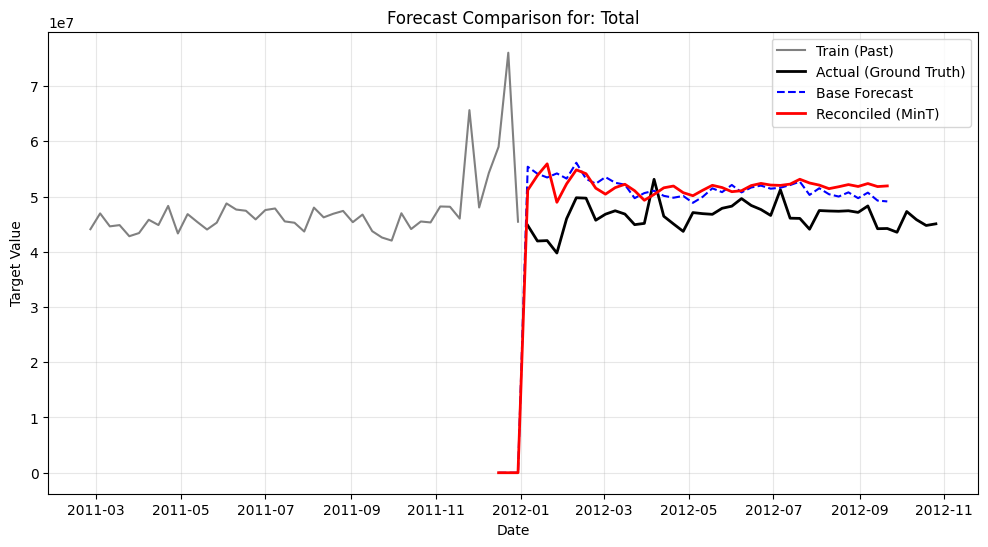

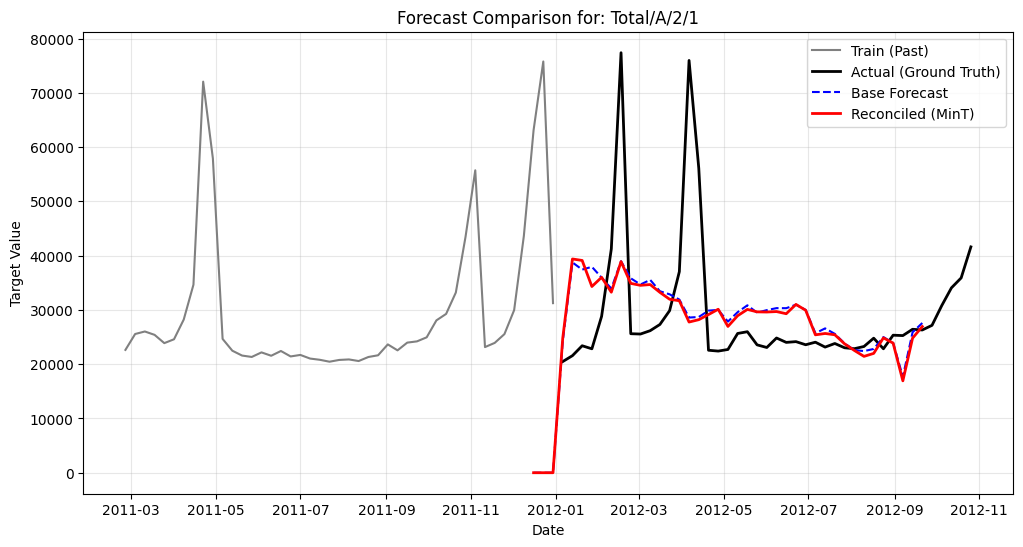

In [73]:
def plot_hierarchical_series(uid, model_name='AutoARIMA'):
    """
    Plots the train, actuals, base forecast, and reconciled forecast for a specific ID.
    model_name: Change to 'HoltWinters' if using the ETS pipeline.
    """
    fig, ax = plt.subplots(figsize=(12, 6))


    train_plot = Y_dfR.loc[Y_dfR['unique_id']==uid]# if uid in Y_train_df.index else Y_train_df[Y_train_df.index == uid]
    test_plot = Y_dfT.loc[Y_dfT['unique_id']==uid]#if uid in Y_test_df.index else Y_test_df[Y_test_df.index == uid]
    pred_plot = Y_rec_sarimax.loc[Y_rec_sarimax['unique_id']==uid]# if uid in Y_rec_df.index else Y_rec_df[Y_rec_df.index == uid]
    ax.plot(train_plot['ds'].tail(45), train_plot['y'].tail(45), label='Train (Past)', color='gray')


    ax.plot(test_plot['ds'], test_plot['y'], label='Actual (Ground Truth)', color='black', linewidth=2)


    ax.plot(pred_plot['ds'], pred_plot[model_name], label='Base Forecast', linestyle='--', color='blue')

    ax.plot(pred_plot['ds'], pred_plot[f'{model_name}/MinTrace_method-mint_shrink'], label='Reconciled (MinT)', color='red', linewidth=2)

    ax.set_title(f"Forecast Comparison for: {uid}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Target Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

# Test the plot on the Top Level (Total Country)
plot_hierarchical_series('Total')

# Test the plot on a Bottom Level (Specific Store)
plot_hierarchical_series('Total/A/2/1')

In [74]:
import matplotlib.pyplot as plt
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape

In [75]:
L=[]
for unique_id in Y_rec_df['unique_id'].unique():
    if unique_id not in Y_dfT['unique_id'].unique():
        L.append(unique_id)

In [76]:
preds = Y_rec_df.loc[~Y_rec_df['unique_id'].isin(L)]

In [77]:
print(preds)
print(Y_dfT)

            unique_id         ds     AutoARIMA  AutoARIMA/BottomUp  \
0               Total 2012-01-13  4.274250e+07        4.628450e+07   
1               Total 2012-01-20  4.839573e+07        4.834035e+07   
2               Total 2012-01-27  4.504718e+07        4.666147e+07   
3               Total 2012-02-03  4.876990e+07        4.791759e+07   
4               Total 2012-02-10  4.580742e+07        4.807873e+07   
...               ...        ...           ...                 ...   
181003  Total/C/44/98 2012-12-21  3.625906e+03        3.625906e+03   
181004  Total/C/44/98 2012-12-28  3.625908e+03        3.625908e+03   
181005  Total/C/44/98 2013-01-04  3.625902e+03        3.625902e+03   
181006  Total/C/44/98 2013-01-11  3.625899e+03        3.625899e+03   
181007  Total/C/44/98 2013-01-18  3.625904e+03        3.625904e+03   

        AutoARIMA/MinTrace_method-mint_shrink  
0                                4.674111e+07  
1                                4.957900e+07  
2              

In [78]:
actuals = Y_dfT[['unique_id', 'ds', 'y']]

#Merge predictions with actual ground truth
eval_df = Y_rec_sarimax.merge(actuals, on=['unique_id', 'ds'])

#Define the models we want to evaluate

models_to_evaluate = ['AutoARIMA', 'AutoARIMA/BottomUp', 'AutoARIMA/MinTrace_method-mint_shrink']

# Calculate metrics using utilsforecast
metrics_df = evaluate(
    df=eval_df,
    metrics=[rmse, mae, mape],
    models=models_to_evaluate
)

print("\n--- Model Evaluation Metrics ---")
# Let's look at the average error across the entire hierarchy
print(metrics_df.groupby('metric')[models_to_evaluate].mean())


--- Model Evaluation Metrics ---
           AutoARIMA  AutoARIMA/BottomUp  \
metric                                     
mae      9195.902916         9845.827909   
mape       43.783132           43.783129   
rmse    10731.917678        11104.136805   

        AutoARIMA/MinTrace_method-mint_shrink  
metric                                         
mae                               9908.368172  
mape                                43.107371  
rmse                             11261.824174  


In [79]:
!pip install mlforecast
!pip install hierarchicalforecast

In [80]:

from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
df1 = df1.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
df1['Total'] = 'Total'

hierarchy_spec = [['Total'],
    ['Total','Type'],
    ['Total','Type','Store'],          # Level 1 below Total
    ['Total','Type','Store', 'Dept']   # Level 2 (Bottom level)
]


train=df1.loc[df1['ds']<='2012-01-06 00:00:00']
test=df1.loc[df1['ds']>'2012-01-06 00:00:00']
valid_combos = train[['Store', 'Dept']].drop_duplicates()



# Filter the test set to ONLY keep those valid combos
test_pruned = test.merge(valid_combos, on=['Store', 'Dept'], how='inner')

ids_with_enough_test = test_pruned.groupby(['Total','Type','Store', 'Dept']).size()
ids_with_enough_test = ids_with_enough_test[ids_with_enough_test >= 38].reset_index()
ids_with_enough_test=ids_with_enough_test.drop([0],axis=1)
trainfiltered=train.merge(ids_with_enough_test,on=['Total','Type','Store', 'Dept'],how='left')
test_prunedfiltered=test_pruned.merge(ids_with_enough_test,on=['Total','Type','Store', 'Dept'],how='left')
Y_dfR, S_dfR, tagsR = aggregate(df=trainfiltered, spec=hierarchy_spec)
Y_dfT, S_dfT, tagsT = aggregate(df=test_prunedfiltered, spec=hierarchy_spec)

In [81]:
from mlforecast.auto import AutoMLForecast, AutoXGBoost
from mlforecast.target_transforms import Differences

def custom_xgb_config(trial):
    # Move fixed preprocessing configurations into the trial-specific configuration
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2),
        # Preprocessing parameters set here
        "lags": [1, 2, 3, 4, 52],
        "date_features": ["month", "week", "quarter"],
        "target_transforms": [Differences([52])],
    }

auto_mlf = AutoMLForecast(
    models=[
        AutoXGBoost(config=custom_xgb_config)
    ],
    freq="W-FRI",
    season_length=52
)

In [82]:
Y_dfR.head()

,unique_id,ds,y
0,Total,2010-02-05,49751012.0
1,Total,2010-02-12,48336924.0
2,Total,2010-02-19,48278812.0
3,Total,2010-02-26,43972312.0
4,Total,2010-03-05,46873960.0


In [83]:
L=Y_dfR.groupby('unique_id').agg('count')

In [84]:
L=L.reset_index()

In [85]:

new=Y_dfR.copy()
for n in L.unique_id:
  if L.loc[L['unique_id']==n,'y'].values[0]!=101:
    new=new.loc[new['unique_id']!=n]


In [86]:
k=new.groupby('unique_id').agg('count')
k

,ds,y
unique_id,,
Total,101,101
Total/A,101,101
Total/A/1,101,101
Total/A/1/1,101,101
Total/A/1/10,101,101
...,...,...
Total/C/44/94,101,101
Total/C/44/95,101,101
Total/C/44/96,101,101


In [87]:
k.sort_values(by='y')

,ds,y
unique_id,,
Total,101,101
Total/B/21/14,101,101
Total/B/21/16,101,101
Total/B/21/17,101,101
Total/B/21/19,101,101
...,...,...
Total/A/33/80,101,101
Total/A/33/81,101,101
Total/A/33/82,101,101


In [88]:
# Updated configuration to fit within the 101-week data limit
# We reduce the lag and difference requirements to prevent empty matrices
def custom_xgb_config(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "lags": [1, 2, 3, 52], # Reduced lags to save history
        "date_features": ["month", "week"],
        "target_transforms": [Differences([1])] # Use 1-week diff instead of 52 if data is short
    }

auto_mlf = AutoMLForecast(
    models=[AutoXGBoost(config=custom_xgb_config)],
    freq="W-FRI",
    season_length=52
)

# Re-running with parameters that respect the 101-row limit
auto_mlf.fit(
    df=new,
    n_windows=1,
    h=26, # Reduced horizon for the validation window to leave more training data
    num_samples=20,
    id_col="unique_id",
    time_col="ds",
    target_col="y",fitted=True
)

# Generate predictions for the next 38 weeks
preds = auto_mlf.predict(h=38)
preds.head()

[I 2026-04-28 23:49:05,247] A new study created in memory with name: no-name-2bfdbd7f-b215-4046-b4a6-d3dca1db1091
[I 2026-04-28 23:49:06,635] Trial 0 finished with value: 0.16508579626912231 and parameters: {'n_estimators': 320, 'learning_rate': 0.051902630176951646, 'max_depth': 5, 'target_transforms_idx': 4, 'lags_idx': 0, 'lag_transforms_idx': 2, 'use_date_features': 0}. Best is trial 0 with value: 0.16508579626912231.
[I 2026-04-28 23:49:07,581] Trial 1 finished with value: 0.10110399171563256 and parameters: {'n_estimators': 108, 'learning_rate': 0.06801737161546002, 'max_depth': 6, 'target_transforms_idx': 1, 'lags_idx': 1, 'lag_transforms_idx': 0, 'use_date_features': 1}. Best is trial 1 with value: 0.10110399171563256.
[I 2026-04-28 23:49:09,095] Trial 2 finished with value: 0.09328450526357265 and parameters: {'n_estimators': 282, 'learning_rate': 0.0370197898330731, 'max_depth': 3, 'target_transforms_idx': 3, 'lags_idx': 2, 'lag_transforms_idx': 2, 'use_date_features': 0}. Be

,unique_id,ds,AutoXGBoost
0,Total,2012-01-13,42766276.0
1,Total,2012-01-20,43079916.0
2,Total,2012-01-27,43109096.0
3,Total,2012-02-03,44814144.0
4,Total,2012-02-10,45382716.0


In [89]:
# Extracting fitted values from the AutoMLForecast object
automl_fitted_values = auto_mlf.forecast_fitted_values()
display(automl_fitted_values.head())

,unique_id,ds,y,AutoXGBoost
0,Total,2011-02-04,46154136.0,44136788.0
1,Total,2011-02-11,47337412.0,46137412.0
2,Total,2011-02-18,48716232.0,47875772.0
3,Total,2011-02-25,44126180.0,45277408.0
4,Total,2011-03-04,46981124.0,44883088.0


In [90]:
reconcilers = [
    BottomUp(),
    MinTrace(method='mint_shrink')
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers)

# 1. Use the unique_ids from the Summing Matrix (S_dfR) to ensure total coverage
# This is crucial: the reconciler must see every series defined in the hierarchy.
all_uids_in_hierarchy = S_dfR['unique_id'].unique()
all_ds_forecast = preds['ds'].unique()

# Create a full template for all hierarchy IDs and all forecast dates
temp_uids = pd.DataFrame({'unique_id': all_uids_in_hierarchy, 'key': 1})
temp_ds = pd.DataFrame({'ds': all_ds_forecast, 'key': 1})
full_forecast_template = pd.merge(temp_uids, temp_ds, on='key').drop('key', axis=1)

# 2. Align base forecasts and fill missing IDs with 0
Y_hat_df_reindexed = pd.merge(full_forecast_template, preds, on=['unique_id', 'ds'], how='left')
Y_hat_df_reindexed['AutoXGBoost'] = Y_hat_df_reindexed['AutoXGBoost'].fillna(0)

# 3. Align fitted values for all hierarchy IDs across all training dates
all_ds_fitted = Y_dfR['ds'].unique()
temp_ds_fitted = pd.DataFrame({'ds': all_ds_fitted, 'key': 1})
full_fitted_template = pd.merge(temp_uids, temp_ds_fitted, on='key').drop('key', axis=1)

# Merge ground truth and AutoML fitted values into the full template
Y_fitted_df_reindexed = pd.merge(full_fitted_template, Y_dfR[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
Y_fitted_df_reindexed = pd.merge(Y_fitted_df_reindexed, automl_fitted_values[['unique_id', 'ds', 'AutoXGBoost']], on=['unique_id', 'ds'], how='left')

# Fill missing values with 0 (essential for IDs we didn't train on)


Y_fitted_df_reindexed['y'] = Y_fitted_df_reindexed['y'].fillna(0)
Y_fitted_df_reindexed['AutoXGBoost'] = Y_fitted_df_reindexed['AutoXGBoost'].fillna(0)

# 4. Reconcile the forecasts
Y_rec_automlf = hrec.reconcile(
    Y_hat_df=Y_hat_df_reindexed,
    Y_df=Y_fitted_df_reindexed,
    S_df=S_dfR,
    tags=tagsR
)

display(Y_rec_automlf.head())

,unique_id,ds,AutoXGBoost,AutoXGBoost/BottomUp,AutoXGBoost/MinTrace_method-mint_shrink
0,Total,2012-01-13,42766276.0,4.330235e+07,3.424970e+07
1,Total,2012-01-20,43079916.0,4.363892e+07,4.045245e+07
2,Total,2012-01-27,43109096.0,4.205661e+07,2.985949e+07
3,Total,2012-02-03,44814144.0,4.505603e+07,4.074653e+07
4,Total,2012-02-10,45382716.0,4.583876e+07,4.442922e+07


In [91]:

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape
actuals = Y_dfT[['unique_id', 'ds', 'y']]

#Merge predictions with actual ground truth
eval_df = Y_rec_automlf.merge(actuals, on=['unique_id', 'ds'])

#Define the models we want to evaluate

models_to_evaluate = ['AutoXGBoost', 'AutoXGBoost/BottomUp', 'AutoXGBoost/MinTrace_method-mint_shrink']

# Calculate metrics using utilsforecast
metrics_df = evaluate(
    df=eval_df,
    metrics=[rmse, mae, mape],
    models=models_to_evaluate
)

print("\n--- Model Evaluation Metrics ---")
# Let's look at the average error across the entire hierarchy
print(metrics_df.groupby('metric')[models_to_evaluate].median())


--- Model Evaluation Metrics ---
        AutoXGBoost  AutoXGBoost/BottomUp  \
metric                                      
mae     1005.450256           1005.450298   
mape       0.157038              0.157038   
rmse    1280.373535           1280.373451   

        AutoXGBoost/MinTrace_method-mint_shrink  
metric                                           
mae                                 1477.735983  
mape                                   0.212716  
rmse                                1841.552139  


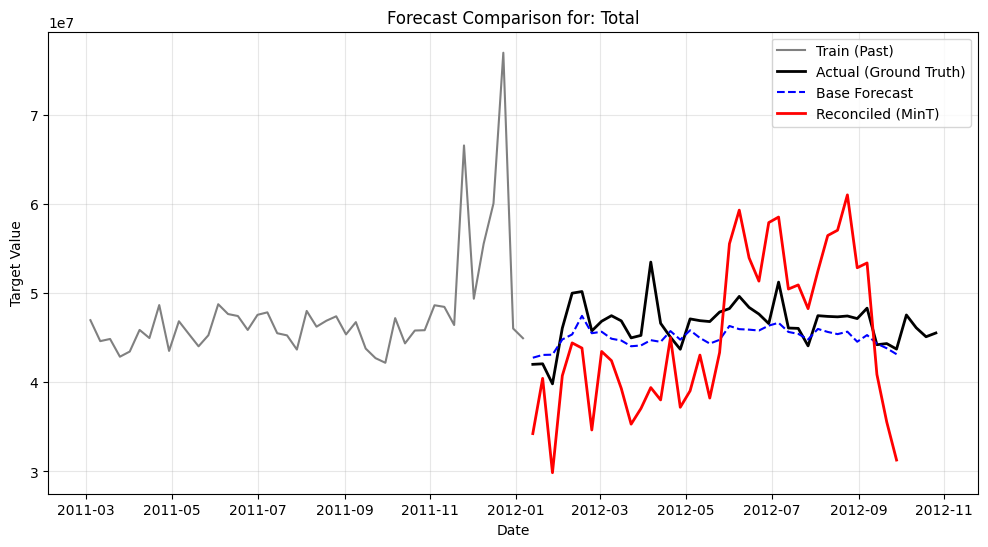

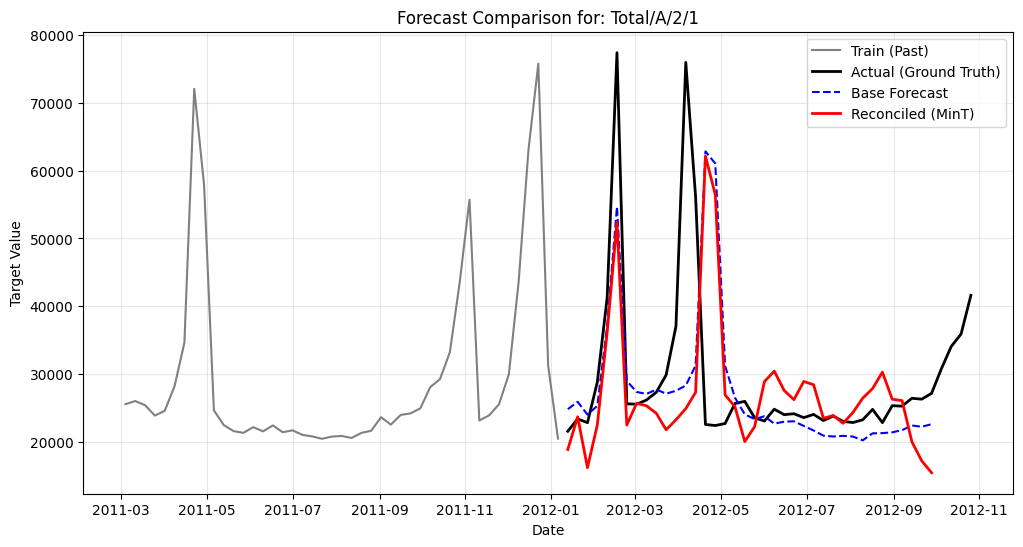

In [92]:
def plot_hierarchical_series(uid, model_name='AutoARIMA'):
    """
    Plots the train, actuals, base forecast, and reconciled forecast for a specific ID.
    model_name: Change to 'HoltWinters' if using the ETS pipeline.
    """
    fig, ax = plt.subplots(figsize=(12, 6))


    train_plot = Y_dfR.loc[Y_dfR['unique_id']==uid]# if uid in Y_train_df.index else Y_train_df[Y_train_df.index == uid]
    test_plot = Y_dfT.loc[Y_dfT['unique_id']==uid]#if uid in Y_test_df.index else Y_test_df[Y_test_df.index == uid]
    pred_plot =Y_rec_automlf.loc[Y_rec_automlf ['unique_id']==uid]# if uid in Y_rec_df.index else Y_rec_df[Y_rec_df.index == uid]
    ax.plot(train_plot['ds'].tail(45), train_plot['y'].tail(45), label='Train (Past)', color='gray')


    ax.plot(test_plot['ds'], test_plot['y'], label='Actual (Ground Truth)', color='black', linewidth=2)


    ax.plot(pred_plot['ds'], pred_plot[model_name], label='Base Forecast', linestyle='--', color='blue')

    ax.plot(pred_plot['ds'], pred_plot[f'{model_name}/MinTrace_method-mint_shrink'], label='Reconciled (MinT)', color='red', linewidth=2)

    ax.set_title(f"Forecast Comparison for: {uid}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Target Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

plot_hierarchical_series('Total','AutoXGBoost')

plot_hierarchical_series('Total/A/2/1','AutoXGBoost')

def makefutureforecasts_fastest(model, df, dfr):
    dfr = dfr.copy()
    n_future = len(dfr)


    lag_history = list(df['Weekly_Sales'].iloc[-3:])

    predictions = []

    for i in range(n_future):
        X_input = dfr.iloc[[i]].copy()


        X_input.insert(loc=len(X_input.columns), column='lag1', value=lag_history[-1])
        X_input.insert(loc=len(X_input.columns), column='lag2', value=lag_history[-2])
        X_input.insert(loc=len(X_input.columns), column='lag3', value=lag_history[-3])
        if 'Weekly_Sales' in X_input.columns:
            X_input = X_input.drop(['Weekly_Sales'], axis=1)


        y_next = model.predict(X_input)[0]


        lag_history.append(y_next)
        lag_history.pop(0)

        predictions.append(y_next)


    L = dfr.copy()
    L['Weekly_Sales'] = predictions
    return L
L=makefutureforecasts_fastest(reg,train,X_test)